## Simple MultiAI Agent Architecture

In [133]:
import os
from dotenv import load_dotenv

from typing import TypedDict, Literal, List, Annotated
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage, AIMessage
from langchain.agents import create_agent
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_community.tools.tavily_search import TavilySearchResults

In [134]:
load_dotenv()

True

In [135]:
class AgentState(MessagesState):
  next_agent: str

In [136]:
# Simple tools using tool decorator
from langchain_core.tools import tool

@tool
def search_web(query: str) -> str:
  """Search information from the web"""
  tavily = TavilySearchResults(max_results=4)
  results = tavily.invoke(query)
  return str(results)

@tool 
def write_summary(content: str) -> str:
  """Write the summary of the provided content"""

  summary = f"Summary of the findings: \n\n{content}"
  return summary

In [137]:
llm = ChatGroq(
  model_name="meta-llama/llama-4-scout-17b-16e-instruct",
  temperature=0
)

In [138]:
def researcher_agent(state: AgentState):
  """Researcher agent that researches information."""

  messages = state["messages"]

  system_message = SystemMessage(content="You are a research assistant. Use the search_web tool to find information about the user's request.")

  researcher_llm = llm.bind_tools([search_web])
  response = researcher_llm.invoke([system_message] + messages)

  return {
    "messages": [response],
    "next_agent": "writer"
  }

def writer_agent(state: AgentState):
  """Writer agent that writes summary of the research"""

  messages = state["messages"]

  system_message = SystemMessage(content="You are a technical writer. Review the conversation and create a clear, concise summary of the findings.")

  response = llm.invoke([system_message] + messages)

  return {
    "messages": [response],
    "next_agent": "end"
  }

In [139]:
from langgraph.prebuilt import ToolNode

# Tool Executor Node
def execute_tool_calls(state: AgentState):
  """Execute any pending tool calls"""

  messages = state["messages"]
  last_message = messages[-1]

  # Check if there are tool calls to execute
  if hasattr(last_message, "tool_calls") and last_message.tool_calls:
    # Create the tool node and execute
    tool_node = ToolNode([search_web, write_summary])
    response = tool_node.invoke(state)

    return response
  

  # If there are no tool calls to execute
  return state

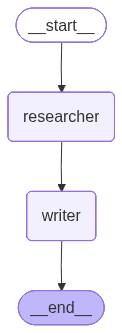

In [140]:
from langgraph.checkpoint.memory import MemorySaver

# Creating simple graph
workflow = StateGraph(MessagesState)

# Memory for the workflow
memory = MemorySaver()

# Add Nodes - 2nd component of the agentic architecture
workflow.add_node('researcher', researcher_agent)
workflow.add_node('writer', writer_agent)

# Add edges - 3rd component of the agentic architecture
workflow.set_entry_point('researcher')
workflow.add_edge('researcher', 'writer')
workflow.add_edge('writer', END)

final_workflow = workflow.compile(checkpointer=memory)

final_workflow

In [141]:
config = {"configurable": {"thread_id": 1}}
response = final_workflow.invoke({"messages": "Research about the viablity, current implementations, and security implications of Artificial Intelligence (AI) in healthcare environments."}, config)

# response = res["messages"][-1].content

In [142]:
for res in response["messages"]:
  res.pretty_print()

================================ Human Message =================================

Research about the viablity, current implementations, and security implications of Artificial Intelligence (AI) in healthcare environments.
================================== Ai Message ==================================
Tool Calls:
  search_web (vhfdh1dn7)
 Call ID: vhfdh1dn7
  Args:
    query: Artificial Intelligence in healthcare environments viability current implementations security implications
================================== Ai Message ==================================


## Supervisor Multi AI Agent Architecture

In [143]:
from typing import TypedDict, Dict, Literal, Annotated, Any, List
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, MessagesState, END
import random
from datetime import datetime

In [166]:
# Defining the state

class SupervisorAgentState(MessagesState):
  """State for the supervisor agent"""
  next_agent: str = ""
  research_data: str = ""
  analysis: str = ""
  final_report: str = ""
  task_complete: bool = False
  current_task: str = ""

In [165]:
# Supervisor chain using groq llm
from langchain_groq import ChatGroq
from langchain_classic.prompts import ChatPromptTemplate

llm = ChatGroq(
  model_name='meta-llama/llama-4-scout-17b-16e-instruct',
  temperature=0
)

def create_supervisor_chain():
  """Creates the supervisor decision chain"""

  supervisor_prompt = ChatPromptTemplate.from_messages(
    [
      ("system", """You are a supervisor managing a team of agents:
        
        1. Researcher - Gathers information and data
        2. Analyst - Analyzes data and provides insights  
        3. Writer - Creates reports and summaries

        Based on the current state and conversation, decide which agent should work next.
        If the task is complete, respond with 'DONE'.

        Current state:
        - Has research data: {has_research}
        - Has analysis: {has_analysis}
        - Has report: {has_report}

        Respond with ONLY the agent name (researcher/analyst/writer) or 'DONE'.
      """),
      ("human", "{task}")
    ]
  )

  return supervisor_prompt | llm

In [167]:
# supervisor agent
def supervisor_agent(state: SupervisorAgentState):
  messages = state['messages']
  # use stored original task, don't re-derive from mutating message list
  task = state.get("current_task") or (messages[0].content if messages else "No Task")

  has_research = bool(state.get("research_data", ""))
  has_analysis = bool(state.get("analysis", ""))
  has_report = bool(state.get("final_report", ""))

  if has_report:
      next_agent = "end"
      supervisor_msg = "✅ Supervisor: All tasks complete! Great work team."
  elif not has_research:
      next_agent = "researcher"
      supervisor_msg = "📋 Supervisor: Let's start with research. Assigning to Researcher..."
  elif not has_analysis:
      next_agent = "analyst"
      supervisor_msg = "📋 Supervisor: Research done. Time for analysis. Assigning to Analyst..."
  else:
      next_agent = "writer"
      supervisor_msg = "📋 Supervisor: Analysis complete. Let's create the report. Assigning to Writer..."

  return {
    "messages": [AIMessage(content=supervisor_msg)],
    "next_agent": next_agent,
    "current_task": task
  }

In [168]:
# Simple tool using tool decorator
from langchain_core.tools import tool

@tool
def search_web(query: str) -> str:
  """Search information from the web"""
  tavily = TavilySearchResults(max_results=2)
  results = tavily.invoke(query)
  return str(results)

In [169]:
# Agent 1: The Researcher Agent
def researcher_agent(state: SupervisorAgentState) -> Dict:
  """this researcher agent uses tavily to gather information"""

  task = state.get("current_task", "research topic")

  research_prompt = f"""
    As a research specialist, find comprehensive information about {task}.

    Include:
    1. Key facts and background
    2. Current trends or developments
    3. Important statistics or data points
    4. Notable examples or case studies
    
    Be concise but thorough.
  """

  researcher_llm = llm.bind_tools([search_web])
  research_response = researcher_llm.invoke([HumanMessage(content=research_prompt)])
  research_data = research_response.content

  agent_message = f"🔍 Researcher: I've completed the research on '{task}'.\n\nKey findings:\n{research_data[:300]}..."

  return {
    "messages": [AIMessage(content=agent_message)],
    "research_data": research_data,
    "next_agent": "supervisor"
  }

In [170]:
# Agent 2: The Analyst Agent
def analyst_agent(state: SupervisorAgentState) -> Dict:
  """this analyst agent uses research information to perform detailed analysis"""

  research_data = state.get("research_data", "")
  task = state.get("current_task", "")

  analysis_prompt = f"""As a data analyst, analyze this research data and provide insights:

  Research Data:
  {research_data}

  Provide:
  1. Key insights and patterns
  2. Strategic implications
  3. Risks and opportunities
  4. Recommendations

  Focus on actionable insights related to: {task}"""

  analysis_response = llm.invoke([HumanMessage(content=analysis_prompt)])
  analysis = analysis_response.content

  # Create agent message
  agent_message = f"📊 Analyst: I've completed the analysis.\n\nTop insights:\n{analysis[:300]}..."

  return {
    "messages": [AIMessage(content=agent_message)],
    "analysis": analysis,
    "next_agent": "supervisor"
  }

In [171]:
# Agent 3: The Writer Agent
def writer_agent(state: SupervisorAgentState) -> Dict:
  """this writer agent uses research information and analysis to generate final report."""

  research_data = state.get("research_data", "")
  analysis = state.get("analysis", "")
  task = state.get("current_task", "")

  writing_prompt = f"""As a professional writer, create an executive report based on:
  
  Task: {task}

  Research Findings:
  {research_data[:500]}

  Analysis:
  {analysis[:500]}

  Create a well-structured report with:
  1. Executive Summary
  2. Key Findings  
  3. Analysis & Insights
  4. Recommendations
  5. Conclusion

  Keep it professional and concise."""

  report_response = llm.invoke([HumanMessage(content=writing_prompt)])
  report = report_response.content

  final_report = f"""
  📄 FINAL REPORT
  {'='*50}
  Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}
  Topic: {task}
  {'='*50}

  {report}

  {'='*50}
  Report compiled by Multi AI Agent System powered by Groq
  """

  # Create agent message
  agent_message = f"✍️ Writer: Report complete! See below for the full document."

  return {
    "messages": [AIMessage(content=agent_message)],
    "final_report": final_report,
    "next_agent": "supervisor",
    "task_complete": True
  }

In [177]:
# Router Function 
def router(state: SupervisorAgentState) -> Literal['supervisor', 'researcher', "analyst", 'writer', '__end__']:
  """Routes the agents based on the agent state"""

  next_agent = state.get("next_agent", "supervisor")

  if next_agent == "end" or state.get("task_complete", False):
    return END
  
  if next_agent in ['supervisor', 'researcher', 'analyst', 'writer']:
    return next_agent
  
  return "supervisor"

In [178]:
workflow = StateGraph(SupervisorAgentState)

workflow.add_node("supervisor", supervisor_agent)
workflow.add_node("researcher", researcher_agent)
workflow.add_node("analyst", analyst_agent)
workflow.add_node("writer", writer_agent)

workflow.set_entry_point("supervisor")

for node in ['supervisor', 'researcher', 'analyst', 'writer']:
  workflow.add_conditional_edges(
    node,
    router,
    {
      "supervisor": "supervisor",
      "researcher": "researcher",
      "analyst": "analyst",
      "writer": "writer",
      END: END
    }
  )


multiagent_graph = workflow.compile()


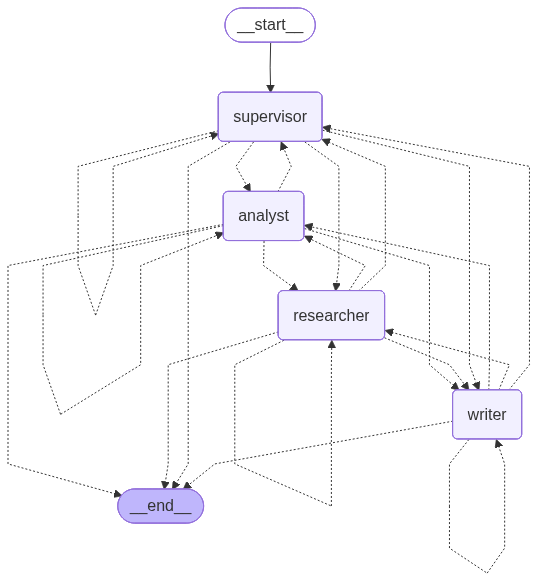

In [174]:
multiagent_graph

In [179]:
response = multiagent_graph.invoke(
    {"messages": [HumanMessage(content="Current adoption of AI coding assistants (GitHub Copilot, Cursor, Claude Code) among individual developers in 2026.")]}
)

KeyboardInterrupt: 

In [176]:
response

{'messages': [HumanMessage(content='Current adoption of AI coding assistants (GitHub Copilot, Cursor, Claude Code) among individual developers in 2026.', additional_kwargs={}, response_metadata={}, id='c3904914-87a3-40d4-89c0-5b43b2bbcaad'),
  AIMessage(content="📋 Supervisor: Let's start with research. Assigning to Researcher...", additional_kwargs={}, response_metadata={}, id='00f46c39-9dea-41eb-a976-7b68981d07c5', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content="🔍 Researcher: I've completed the research on 'Current adoption of AI coding assistants (GitHub Copilot, Cursor, Claude Code) among individual developers in 2026.'.\n\nKey findings:\n...", additional_kwargs={}, response_metadata={}, id='00f04fd5-bd98-44de-9a04-df163f6193e1', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content="📋 Supervisor: Let's start with research. Assigning to Researcher...", additional_kwargs={}, response_metadata={}, id='291a1525-bb61-4532-8de5-0b387319239d', tool_calls=[], invalid_tool_